## Section 1 — Environment Setup & Imports

**What this does:**
This cell centralizes all necessary library imports, sets up global constants (like the dataset path), configures the computation device (CPU or GPU), and seeds the random number generators for reproducibility.

**Reasoning:**
In a production-quality notebook, imports should never be scattered. Centralizing them at the top makes the environment dependencies explicit and ensures the notebook fails fast if a package is missing. Setting fixed global seeds (`42`) is a critical ML best practice to ensure that debugging is deterministic and experiments are reproducible. Using constants for paths makes the code portable.

**Expected Output:**
The cell will output a string indicating whether a CUDA GPU is available and actively selected (e.g., `Using device: cuda`), which confirms our hardware acceleration is properly configured.

In [1]:
# from google.colab import drive
# drive.mount('/content/drive')

In [2]:
import os
import random
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, random_split, WeightedRandomSampler, ConcatDataset
import torchvision
from torchvision import transforms
from torchvision.datasets import ImageFolder
from torchvision.models import EfficientNet_B0_Weights, ViT_B_16_Weights
import torchmetrics
from sklearn.metrics import confusion_matrix

# Global Constants
DATASET_PATH = "image_data"

# Global Seeds for Reproducibility
def seed_everything(seed: int = 42):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything(42)

# Device Configuration
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

Using device: cuda


## Section 2 — Dataset Exploration & Class Imbalance Analysis

**What this does:**
This cell loads the dataset with a minimal transformation purely for exploratory data analysis (EDA), counts the number of samples in each class, calculates the imbalance ratio, and plots the distribution as a bar chart.

**Reasoning:**
Inspecting class distribution before making any modeling decisions is a mandatory first step. Skipping this can lead to accuracy paradoxes where a model achieves "high accuracy" simply by predicting the majority class. Because we are working with a very small dataset (~400 images total), knowing the exact imbalance dictates our need for weighted sampling and weighted loss functions downstream.

**Expected Output:**
Text output showing the class-to-index mapping, total counts, and imbalance ratio. A matplotlib bar chart visually demonstrating the ~250 (AI) vs ~150 (Real) sample disparity.

Class to Index Mapping: {'Ai_generated_dataset': 0, 'real_dataset': 1}
Total images: 995
Ai_generated_dataset (Class 0): 250 images
real_dataset (Class 1): 745 images
Imbalance Ratio (AI to Real): 0.34:1


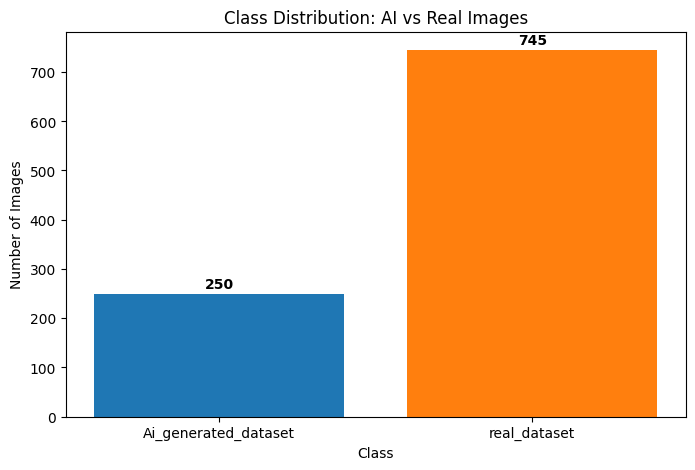

In [3]:
# Minimal transform strictly for EDA
eda_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

eda_dataset = ImageFolder(root=DATASET_PATH, transform=eda_transform)

class_names = eda_dataset.classes
class_to_idx = eda_dataset.class_to_idx
print(f"Class to Index Mapping: {class_to_idx}")

# Count instances per class
targets = eda_dataset.targets
class_counts = [targets.count(i) for i in range(len(class_names))]
total_count = sum(class_counts)

print(f"Total images: {total_count}")
for i, name in enumerate(class_names):
    print(f"{name} (Class {i}): {class_counts[i]} images")

imbalance_ratio = class_counts[0] / class_counts[1]
print(f"Imbalance Ratio (AI to Real): {imbalance_ratio:.2f}:1")

# Plot distribution
plt.figure(figsize=(8, 5))
plt.bar(class_names, class_counts, color=['#1f77b4', '#ff7f0e'])
plt.title('Class Distribution: AI vs Real Images')
plt.ylabel('Number of Images')
plt.xlabel('Class')
for i, count in enumerate(class_counts):
    plt.text(i, count + 5, str(count), ha='center', va='bottom', fontweight='bold')
plt.show()

## Section 3 — Augmentation Strategy & Shared Eval Transform

**What this does:**
Defines two transformation pipelines: `train_transforms` applies geometric and color augmentations, while `eval_transforms` strictly resizes and normalizes the images.

**Reasoning:**
1. Augmentation is applied *only* to training data to prevent data leakage and ensure the validation/test sets accurately represent real-world data.
2. Online augmentation (via PyTorch `transforms`) is vastly superior to offline augmentation for small datasets because it dynamically applies random variations during every epoch, practically providing infinite variations of the training data without ballooning disk space.
3. We intentionally exclude heavy blurring or Gaussian noise. AI-generated images often contain microscopic high-frequency artifacts (e.g., GAN checkerboard patterns or diffusion blur). Destroying these through augmentation would eliminate the exact signal the model needs to learn.
4. ImageNet normalization is utilized, which is mathematically sound even for custom models trained from scratch, as our data consists of natural, RGB images that share similar statistical distributions to ImageNet.

**Expected Output:**
Two `torchvision.transforms.Compose` objects stored in memory. No visual output.

In [4]:
train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.2),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2),
    transforms.RandomRotation(degrees=15),
    transforms.RandomGrayscale(p=0.05),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

eval_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

## Section 4 — Train/Val/Test Split Utility & WeightedRandomSampler

**What this does:**
Defines a reusable function `build_dataloaders` that loads the data, splits it into Train/Validation/Test sets, and handles class imbalances using a `WeightedRandomSampler` on the training set.

**Reasoning:**
1. Validation and Test splits must use `eval_transforms` (not `train_transforms`) so metrics reflect performance on clean, unaltered images.
2. The `WeightedRandomSampler` is a DataLoader-level intervention. It calculates the inverse frequency of each class and oversamples the minority class during batch generation. This ensures that every batch the model sees is balanced (approx 50/50 AI vs Real), stabilizing gradient updates without writing duplicated data to disk.
3. A fixed seed (`Generator().manual_seed(42)`) guarantees the exact same train/val/test splits across runs, ensuring apples-to-apples model comparisons.
4. The `use_combined_train_val` flag enables training on the combined 85% of data (Train + Val) for final production runs on transfer learning models, maximizing data usage before the final Test set evaluation.

**Expected Output:**
A function definition. No executed output.

In [5]:
def build_dataloaders(
    dataset_path: str,
    train_transform: transforms.Compose,
    eval_transform: transforms.Compose,
    train_ratio: float = 0.70,
    val_ratio: float = 0.15,
    batch_size: int = 32,
    use_combined_train_val: bool = False
) -> tuple[DataLoader, DataLoader, DataLoader, list]:

    # Load dataset twice to map different transforms to different splits
    dataset_train = ImageFolder(root=dataset_path, transform=train_transform)
    dataset_eval = ImageFolder(root=dataset_path, transform=eval_transform)

    total_len = len(dataset_train)
    train_len = int(train_ratio * total_len)
    val_len = int(val_ratio * total_len)
    test_len = total_len - train_len - val_len

    generator = torch.Generator().manual_seed(42)

    # Generate identical indices for both datasets
    train_subset_train, val_subset_train, test_subset_train = random_split(
        dataset_train, [train_len, val_len, test_len], generator=generator
    )

    train_subset_eval, val_subset_eval, test_subset_eval = random_split(
        dataset_eval, [train_len, val_len, test_len], generator=generator
    )

    # Always use eval transforms for val and test
    val_dataset = val_subset_eval
    test_dataset = test_subset_eval

    if use_combined_train_val:
        # For production/transfer learning: train on 85% of data
        active_train_dataset = ConcatDataset([train_subset_train, val_subset_train])
    else:
        active_train_dataset = train_subset_train

    # Calculate weights for the WeightedRandomSampler
    # We must extract targets safely from the subsets/concat datasets
    train_targets = []
    if use_combined_train_val:
        for idx in train_subset_train.indices:
            train_targets.append(dataset_train.targets[idx])
        for idx in val_subset_train.indices:
            train_targets.append(dataset_train.targets[idx])
    else:
        for idx in train_subset_train.indices:
            train_targets.append(dataset_train.targets[idx])

    class_counts = [train_targets.count(0), train_targets.count(1)]
    class_weights = 1.0 / torch.tensor(class_counts, dtype=torch.float)
    sample_weights = [class_weights[t] for t in train_targets]

    sampler = WeightedRandomSampler(
        weights=sample_weights,
        num_samples=len(sample_weights),
        replacement=True
    )

    train_dataloader = DataLoader(active_train_dataset, batch_size=batch_size, sampler=sampler)
    val_dataloader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
    test_dataloader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

    return train_dataloader, val_dataloader, test_dataloader, dataset_train.classes

## Section 5 — Shared Metric & Loss Utilities

**What this does:**
Initializes the evaluation metrics (Accuracy, F1, Precision, Recall) using `torchmetrics` and constructs a weighted Cross-Entropy loss function based on the overall dataset's inverse class frequencies.

**Reasoning:**
1. A weighted loss function (`nn.CrossEntropyLoss(weight=...)`) penalizes the model heavier for misclassifying the minority class. This acts as a second line of defense against imbalance, complementing the `WeightedRandomSampler`.
2. PyTorch models expect input tensors and operational objects to reside on the same hardware. Thus, `torchmetrics` objects must explicitly be moved `.to(device)` to avoid runtime memory placement errors during GPU execution.

**Expected Output:**
Metric and loss function objects successfully instantiated and moved to device memory.

In [6]:
# Initialize metrics
# All switched to task="binary" for an elegant, unified metric tracking setup
acc_fn = torchmetrics.Accuracy(task="binary").to(device)
f1_fn = torchmetrics.F1Score(task="binary").to(device)
precision_fn = torchmetrics.Precision(task="binary").to(device)
recall_fn = torchmetrics.Recall(task="binary").to(device)

# Compute inverse frequency weights for the loss function (Used for downstream models if needed)
weights = 1.0 / torch.tensor(class_counts, dtype=torch.float)
weights[1] = weights[1] * 5.0 # Penalize False Positives for AI-Generated by giving Real class 5x weight
class_weights_tensor = (weights / weights.sum()).to(device)

# Loss Functions
weighted_loss_fn = nn.CrossEntropyLoss(weight=class_weights_tensor)
standard_loss_fn = nn.CrossEntropyLoss() # <-- Added for Model 0 to prevent double-imbalance correction

## Section 6 — Generic Train Step & Test Step Functions

**What this does:**
Defines standard `train_step` and `test_step` functions that execute the forward pass, backward pass (for training), loss calculation, and metric accumulation over a single epoch.

**Reasoning:**
Both functions call `.reset()` on all metric objects immediately at the start. `torchmetrics` objects are stateful; they accumulate values over batches internally. If we fail to reset them, the accuracy of Epoch 2 will mistakenly include the buffers from Epoch 1, rendering our statistics entirely invalid. Returning a dictionary of results per step allows our training loop to elegantly store and plot the historical progression of the model without cluttering the output log.

**Expected Output:**
Two function definitions with full type hints.

In [7]:
def train_step(
    model: torch.nn.Module,
    data_loader: DataLoader,
    loss_fn: torch.nn.Module,
    optimizer: torch.optim.Optimizer,
    acc_fn: torchmetrics.Metric,
    f1_fn: torchmetrics.Metric,
    precision_fn: torchmetrics.Metric,
    recall_fn: torchmetrics.Metric,
    device: str
) -> dict:

    # Crucial: Reset metric states before accumulating new epoch data
    acc_fn.reset()
    f1_fn.reset()
    precision_fn.reset()
    recall_fn.reset()

    model.train()
    train_loss = 0.0

    for X, y in data_loader:
        X, y = X.to(device), y.to(device)

        y_pred_logits = model(X)
        y_pred_probs = torch.softmax(y_pred_logits, dim=1)[:, 1] # Probability of class 1

        loss = loss_fn(y_pred_logits, y)
        train_loss += loss.item()

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # Accumulate metrics
        acc_fn(y_pred_probs, y)
        f1_fn(y_pred_probs, y)
        precision_fn(y_pred_probs, y)
        recall_fn(y_pred_probs, y)

    return {
        "loss": train_loss / len(data_loader),
        "accuracy": acc_fn.compute().item(),
        "f1": f1_fn.compute().item(),
        "precision": precision_fn.compute().item(),
        "recall": recall_fn.compute().item()
    }

def test_step(
    model: torch.nn.Module,
    data_loader: DataLoader,
    loss_fn: torch.nn.Module,
    acc_fn: torchmetrics.Metric,
    f1_fn: torchmetrics.Metric,
    precision_fn: torchmetrics.Metric,
    recall_fn: torchmetrics.Metric,
    device: str
) -> dict:

    # Crucial: Reset metric states
    acc_fn.reset()
    f1_fn.reset()
    precision_fn.reset()
    recall_fn.reset()

    model.eval()
    test_loss = 0.0

    with torch.inference_mode():
        for X, y in data_loader:
            X, y = X.to(device), y.to(device)

            y_pred_logits = model(X)
            y_pred_probs = torch.softmax(y_pred_logits, dim=1)[:, 1]

            loss = loss_fn(y_pred_logits, y)
            test_loss += loss.item()

            acc_fn(y_pred_probs, y)
            f1_fn(y_pred_probs, y)
            precision_fn(y_pred_probs, y)
            recall_fn(y_pred_probs, y)

    return {
        "loss": test_loss / len(data_loader),
        "accuracy": acc_fn.compute().item(),
        "f1": f1_fn.compute().item(),
        "precision": precision_fn.compute().item(),
        "recall": recall_fn.compute().item()
    }

## Section 7 — Generic Training Loop & History Plotter

**What this does:**
Provides `train_model` to orchestrate epochs, calling train and validation steps, and `plot_history` to generate dual Matplotlib subplots visualizing the performance trajectories. It also handles model artifact saving.

**Reasoning:**
1. We use `val_loader` continuously during training to track generalization and identify overfitting. The test set is absolutely held out; evaluating the test set inside the training loop is a massive anti-pattern that leads to implicit data leakage.
2. Including `torch.save` natively inside the training loop ensures checkpoints are immediately written to disk upon completion, drastically reducing the risk of losing a successful model to a kernel crash or notebook timeout.

**Expected Output:**
Function definitions ready to be called by individual models.

In [8]:
from tqdm import tqdm

def train_model(
    model: torch.nn.Module,
    train_loader: DataLoader,
    val_loader: DataLoader,
    loss_fn: torch.nn.Module,
    optimizer: torch.optim.Optimizer,
    epochs: int,
    acc_fn: torchmetrics.Metric,
    f1_fn: torchmetrics.Metric,
    precision_fn: torchmetrics.Metric,
    recall_fn: torchmetrics.Metric,
    device: str,
    model_name: str
) -> dict:

    history = {
        "train_loss": [], "train_acc": [],
        "val_loss": [], "val_acc": []
    }

    for epoch in tqdm(range(epochs), desc=f"Training {model_name}"):
        train_metrics = train_step(model, train_loader, loss_fn, optimizer, acc_fn, f1_fn, precision_fn, recall_fn, device)
        val_metrics = test_step(model, val_loader, loss_fn, acc_fn, f1_fn, precision_fn, recall_fn, device)

        history["train_loss"].append(train_metrics["loss"])
        history["train_acc"].append(train_metrics["accuracy"])
        history["val_loss"].append(val_metrics["loss"])
        history["val_acc"].append(val_metrics["accuracy"])

    save_path = f"{model_name}.pth"
    torch.save(model.state_dict(), save_path)
    print(f"\nModel saved to: {save_path}")

    return history

def plot_history(history: dict, model_name: str) -> None:
    epochs = range(1, len(history["train_loss"]) + 1)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
    fig.suptitle(f"{model_name} Training History", fontsize=14)

    ax1.plot(epochs, history["train_loss"], label="Train Loss", marker="o")
    ax1.plot(epochs, history["val_loss"], label="Val Loss", marker="o")
    ax1.set_title("Loss Curves")
    ax1.set_xlabel("Epochs")
    ax1.set_ylabel("Loss")
    ax1.legend()

    ax2.plot(epochs, history["train_acc"], label="Train Accuracy", marker="o")
    ax2.plot(epochs, history["val_acc"], label="Val Accuracy", marker="o")
    ax2.set_title("Accuracy Curves")
    ax2.set_xlabel("Epochs")
    ax2.set_ylabel("Accuracy")
    ax2.legend()

    plt.tight_layout()
    plt.show()

## Section 8 — Model 0: TinyVGG CNN (Trained From Scratch)

**What this does:**
We build a custom, lightweight CNN architecture (TinyVGG) initialized with random weights, and train it strictly on our augmented data without the combined train/val set. Finally, we plot its performance and evaluate the model using a confusion matrix on the held-out test data.

**Reasoning:**
Model 0 serves as our absolute baseline. By constructing a simple CNN from scratch, we establish a performance floor. If our transfer learning models (EfficientNet/ViT) cannot beat Model 0, we know something is fundamentally wrong with our fusion logic or weight freezing strategy. The test set is evaluated exactly once at the end of training to measure absolute generalizability.

**Expected Output:**
Dataloader statistics printed, progress bar output, dual plot visualization of accuracy/loss, final metric printouts, and a confusion matrix heatmap.

Verification: Output shape for a single batch is [1, 2] (Expected [1, 2])
Train batches: 22 | Val batches: 5 | Test batches: 5


Training model_0_tinyvgg: 100%|██████████| 15/15 [05:29<00:00, 22.00s/it]



Model saved to: model_0_tinyvgg.pth


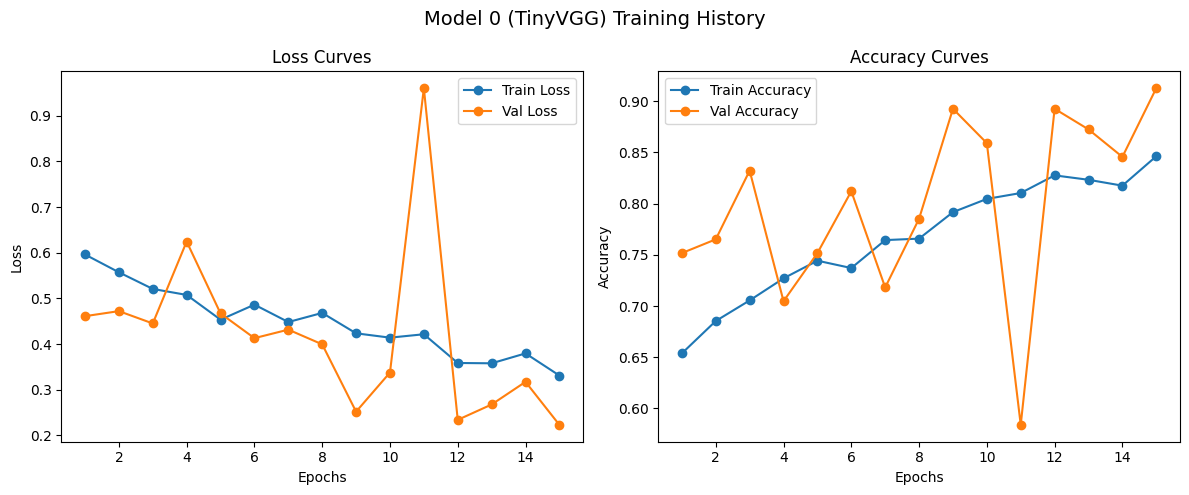


--- Final Test Evaluation: Model 0 ---
Test Accuracy:  0.9400
Test F1 Score:  0.9585
Test Precision: 0.9455
Test Recall:    0.9720


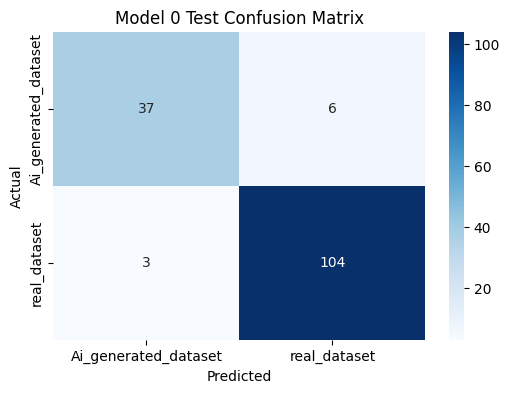

In [9]:
# --- Sub-cell 8a: Upgraded TinyVGG Architecture ---
seed_everything(42)

# class TinyVGG(nn.Module):
    # def __init__(self, in_channels: int, num_classes: int):
    #     super().__init__()

    #     # Block 1: 3 -> 32 channels + BatchNorm
    #     self.block_1 = nn.Sequential(
    #         nn.Conv2d(in_channels, 32, kernel_size=3, padding=1),
    #         nn.BatchNorm2d(32), # Added for gradient stabilization
    #         nn.ReLU(),
    #         nn.MaxPool2d(kernel_size=2)
    #     )

    #     # Block 2: 32 -> 64 channels + BatchNorm
    #     self.block_2 = nn.Sequential(
    #         nn.Conv2d(32, 64, kernel_size=3, padding=1),
    #         nn.BatchNorm2d(64), # Added for gradient stabilization
    #         nn.ReLU(),
    #         nn.MaxPool2d(kernel_size=2)
    #     )

    #     # Block 3: 64 -> 128 channels + BatchNorm
    #     self.block_3 = nn.Sequential(
    #         nn.Conv2d(64, 128, kernel_size=3, padding=1),
    #         nn.BatchNorm2d(128), # Added for gradient stabilization
    #         nn.ReLU(),
    #         nn.MaxPool2d(kernel_size=2)
    #     )

    #     # Adaptive pooling to dramatically reduce parameter footprint
    #     self.pool = nn.AdaptiveAvgPool2d((4, 4))

    #     # Classifier Head: Features reduced from 100,352 down to 2,048 (128 channels * 4 * 4 spatial)
    #     self.classifier = nn.Sequential(
    #         nn.Flatten(),
    #         nn.Dropout(0.4),
    #         nn.Linear(128 * 4 * 4, 256),
    #         nn.ReLU(),
    #         nn.Linear(256, num_classes)
    #     )

    # def forward(self, x: torch.Tensor) -> torch.Tensor:
    #     x = self.block_1(x)
    #     x = self.block_2(x)
    #     x = self.block_3(x)
    #     x = self.pool(x)
    #     return self.classifier(x)
class TinyVGG(nn.Module):
    def __init__(self, in_channels: int, num_classes: int):
        super().__init__()

        def conv_block(in_c, out_c):
            return nn.Sequential(
                nn.Conv2d(in_c, out_c, kernel_size=3, padding=1),
                nn.BatchNorm2d(out_c),
                nn.ReLU(),
                nn.Conv2d(out_c, out_c, kernel_size=3, padding=1),  # second conv
                nn.BatchNorm2d(out_c),
                nn.ReLU(),
                nn.MaxPool2d(kernel_size=2)
            )

        self.block_1 = conv_block(in_channels, 32)
        self.block_2 = conv_block(32, 64)
        self.block_3 = conv_block(64, 128)

        self.pool = nn.AdaptiveAvgPool2d((1, 1))   # Global Average Pool

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.5),                        # slightly higher dropout
            nn.Linear(128, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.block_1(x)
        x = self.block_2(x)
        x = self.block_3(x)
        x = self.pool(x)
        return self.classifier(x)

model_0 = TinyVGG(in_channels=3, num_classes=2).to(device)

# Quick structural verification test
dummy_tensor = torch.randn(1, 3, 224, 224).to(device)
with torch.no_grad():
    output_shape = model_0(dummy_tensor).shape
print(f"Verification: Output shape for a single batch is {list(output_shape)} (Expected [1, 2])")


# --- Sub-cell 8b: Data Loading ---
train_dl_0, val_dl_0, test_dl_0, _ = build_dataloaders(
    dataset_path=DATASET_PATH,
    train_transform=train_transforms,
    eval_transform=eval_transforms,
    use_combined_train_val=False
)
print(f"Train batches: {len(train_dl_0)} | Val batches: {len(val_dl_0)} | Test batches: {len(test_dl_0)}")


# --- Sub-cell 8c: Optimized Hyperparameters & Training Loop Execution ---
# Switched learning rate from an inert 1e-6 to a robust 1e-3
optimizer_0 = torch.optim.AdamW(model_0.parameters(), lr=1e-3, weight_decay=0.01)

# Integrated standard loss function to let WeightedRandomSampler handle class balance natively
history_0 = train_model(
    model=model_0,
    train_loader=train_dl_0,
    val_loader=val_dl_0,
    loss_fn=standard_loss_fn,
    optimizer=optimizer_0,
    epochs=15,
    acc_fn=acc_fn, f1_fn=f1_fn, precision_fn=precision_fn, recall_fn=recall_fn,
    device=device,
    model_name="model_0_tinyvgg"
)
plot_history(history_0, "Model 0 (TinyVGG)")


# --- Sub-cell 8d: Metrics Performance Check ---
print("\n--- Final Test Evaluation: Model 0 ---")
test_metrics_0 = test_step(model_0, test_dl_0, standard_loss_fn, acc_fn, f1_fn, precision_fn, recall_fn, device)
print(f"Test Accuracy:  {test_metrics_0['accuracy']:.4f}")
print(f"Test F1 Score:  {test_metrics_0['f1']:.4f}")
print(f"Test Precision: {test_metrics_0['precision']:.4f}")
print(f"Test Recall:    {test_metrics_0['recall']:.4f}")


# --- Sub-cell 8e: Confusion Matrix Visualization ---
def plot_confusion_matrix(model: nn.Module, data_loader: DataLoader, device: str, title: str):
    model.eval()
    y_true, y_pred = [], []
    with torch.inference_mode():
        for X, y in data_loader:
            X = X.to(device)
            logits = model(X)
            preds = torch.argmax(logits, dim=1)
            y_true.extend(y.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
    plt.title(title)
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.show()

plot_confusion_matrix(model_0, test_dl_0, device, "Model 0 Test Confusion Matrix")

In [10]:
torch.save(model_0.state_dict(), "TinyVGG:model_0.pth")

## Section 10 — LIME Interpretability
**What this does:** Uses Local Interpretable Model-Agnostic Explanations to generate superpixel boundaries showing which parts of an image contributed to the model's decision.

/home/allkeeey/projects/ai-vs-real-detector/venv/lib64/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Generating LIME explanation for Class: real_dataset...


100%|██████████| 1000/1000 [00:05<00:00, 173.29it/s]


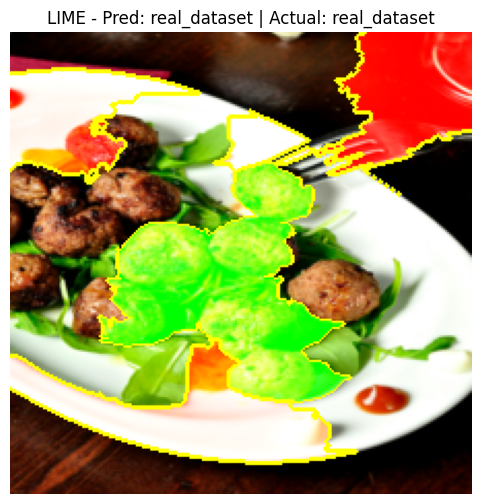

In [11]:
import lime
from lime import lime_image
from skimage.segmentation import mark_boundaries
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn.functional as F
from torchvision import transforms

explainer = lime_image.LimeImageExplainer()

def predict_fn_lime(images):
    model_0.eval()
    device = next(model_0.parameters()).device

    batch = torch.tensor(images, dtype=torch.float32).permute(0, 3, 1, 2)
    normalize = transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    batch = torch.stack([normalize(img) for img in batch]).to(device)

    with torch.inference_mode():
        logits = model_0(batch)
        probs = F.softmax(logits, dim=1)

    return probs.cpu().numpy()

model_0.eval()
sample_img_tensor, sample_label = next(iter(test_dl_0))
sample_img_tensor = sample_img_tensor[0]
sample_label = sample_label[0].item()

inv_normalize = transforms.Normalize(
    mean=[-0.485/0.229, -0.456/0.224, -0.406/0.225],
    std=[1/0.229, 1/0.224, 1/0.225]
)
img_for_lime = inv_normalize(sample_img_tensor).permute(1, 2, 0).cpu().numpy()
img_for_lime = np.clip(img_for_lime, 0, 1)

print(f"Generating LIME explanation for Class: {class_names[sample_label]}...")
explanation = explainer.explain_instance(
    img_for_lime,
    predict_fn_lime,
    top_labels=2,
    hide_color=0,
    num_samples=1000
)

temp, mask = explanation.get_image_and_mask(explanation.top_labels[0], positive_only=False, num_features=10, hide_rest=False)
plt.figure(figsize=(6,6))
plt.imshow(mark_boundaries(temp, mask))
plt.title(f"LIME - Pred: {class_names[explanation.top_labels[0]]} | Actual: {class_names[sample_label]}")
plt.axis('off')
plt.show()


## Section 11 — SHAP Interpretability
**What this does:** Uses SHapley Additive exPlanations (GradientExplainer) to produce pixel-level attribution maps.

Generating SHAP explanations...


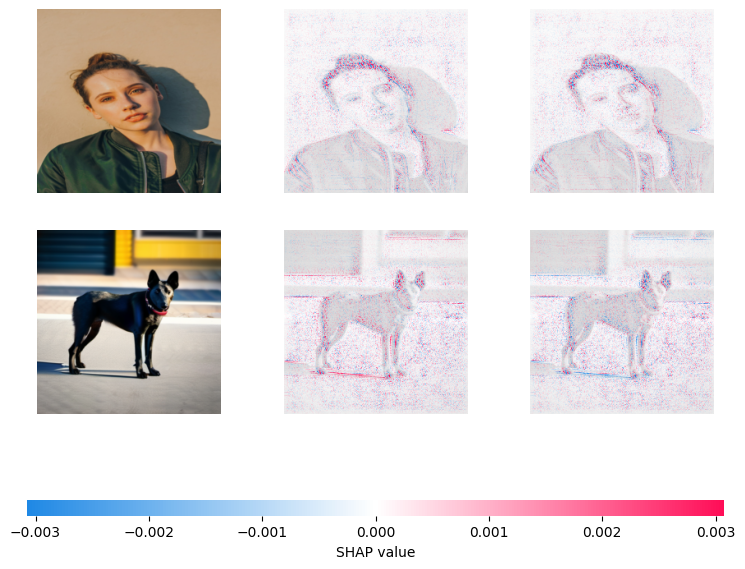

In [12]:
import shap
import numpy as np

batch = next(iter(test_dl_0))
images, labels = batch
images = images.to(device)

print("Generating SHAP explanations...")
background = images[:24]
test_images = images[22:24] # Take 2 images for SHAP to avoid out-of-memory

explainer_shap = shap.GradientExplainer(model_0, background)
shap_values = explainer_shap.shap_values(test_images)

# --- FIX START ---
# The shap_values from GradientExplainer can be a list of arrays or a single 5D array (N, C, H, W, K).
# We need to ensure it's a list of (N, H, W, C) arrays for shap.image_plot.

shap_numpy = []
if isinstance(shap_values, list):
    # This is the typical case: list of (N, C, H, W) arrays, one per class
    shap_numpy = [np.transpose(s, (0, 2, 3, 1)) for s in shap_values]
elif isinstance(shap_values, np.ndarray) and shap_values.ndim == 5:
    # Handles the observed 5D array case: (N, C, H, W, K)
    num_classes = shap_values.shape[-1]
    for i in range(num_classes):
        # Extract shap_values for one class, resulting shape (N, C, H, W)
        s_class_i = shap_values[..., i]
        # Convert from (N, C, H, W) to (N, H, W, C)
        s_class_i_HWC = np.transpose(s_class_i, (0, 2, 3, 1))
        shap_numpy.append(s_class_i_HWC)
else:
    # Fallback for single output models where shap_values is (N, C, H, W)
    shap_numpy = np.transpose(shap_values, (0, 2, 3, 1))

# Convert test_images from (N, C, H, W) to (N, H, W, C)
test_numpy = np.transpose(test_images.cpu().numpy(), (0, 2, 3, 1))
# --- FIX END ---

mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])
test_numpy = std * test_numpy + mean
test_numpy = np.clip(test_numpy, 0, 1)

shap.image_plot(shap_numpy, test_numpy)
